In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [6]:
X_train = pd.read_csv("X_train.csv")
y_train = pd.read_csv("y_train.csv")        
X_test = pd.read_csv("X_test.csv")
y_test = pd.read_csv("y_test.csv")

In [21]:
variances = X_train.var(axis=0)
print(" Variance distribution (on train set):")
print(f"    min    : {variances.min():.6f}")
print(f"    median : {variances.median():.6f}")
print(f"    mean   : {variances.mean():.6f}")
print(f"    max    : {variances.max():.6f}\n")

thresholds = [0.0, 0.001, 0.01]
threshold_labels = ["0.0 (exact zero only)", "0.001 (very low)", "0.01 (low)"]

for thresh, label in zip(thresholds, threshold_labels):
    n_removed = (variances <= thresh).sum()
    print(f"  Threshold {label:<23} → removes {n_removed:>3} features "
          f"({n_removed / len(variances) * 100:.1f}%)")

 Variance distribution (on train set):
    min    : 0.001665
    median : 0.070603
    mean   : 0.242389
    max    : 80.553185

  Threshold 0.0 (exact zero only)   → removes   0 features (0.0%)
  Threshold 0.001 (very low)        → removes   0 features (0.0%)
  Threshold 0.01 (low)              → removes  37 features (6.6%)


In [42]:
from sklearn.feature_selection import VarianceThreshold

VARIANCE_THRESHOLD = 0.01
selector = VarianceThreshold(threshold=VARIANCE_THRESHOLD)
selector.fit(X_train)

removed_var_cols = X_train.columns[~selector.get_support()].tolist()
kept_cols        = X_train.columns[selector.get_support()].tolist()

X_train_clean = selector.transform(X_train)
X_test_clean  = selector.transform(X_test)

print(f"\n  Using threshold = {VARIANCE_THRESHOLD}")
print(f"  Features removed (near-zero var) : {len(removed_var_cols)}")
print(f"  Features kept                    : {len(kept_cols)}")
if removed_var_cols:
    print(f"  Removed examples                 : {removed_var_cols[:8]}")




  Using threshold = 0.01
  Features removed (near-zero var) : 37
  Features kept                    : 525
  Removed examples                 : ['tBodyAcc-mean()-X', 'tBodyAcc-mean()-Y', 'tBodyAcc-mean()-Z', 'tGravityAcc-std()-X', 'tGravityAcc-std()-Y', 'tGravityAcc-mad()-X', 'tGravityAcc-mad()-Y', 'tGravityAcc-iqr()-X']


In [40]:
X_train_clean

array([[ 1.0000000e+00, -9.9527860e-01, -9.8311061e-01, ...,
        -8.4124676e-01,  1.7994061e-01, -5.8626924e-02],
       [ 1.0000000e+00, -9.9824528e-01, -9.7530022e-01, ...,
        -8.4478760e-01,  1.8028889e-01, -5.4316717e-02],
       [ 1.0000000e+00, -9.9537956e-01, -9.6718701e-01, ...,
        -8.4893347e-01,  1.8063731e-01, -4.9117815e-02],
       ...,
       [ 3.0000000e+01, -2.1821818e-01, -1.0382198e-01, ...,
        -7.7913261e-01,  2.4914484e-01,  4.0811188e-02],
       [ 3.0000000e+01, -2.1913944e-01, -1.1141169e-01, ...,
        -7.8518142e-01,  2.4643223e-01,  2.5339478e-02],
       [ 3.0000000e+01, -2.6927044e-01, -8.7211541e-02, ...,
        -7.8326693e-01,  2.4680852e-01,  3.6694843e-02]])

In [43]:
from models import get_models, train_and_evaluate

models = get_models()
models

{'Decision Tree': DecisionTreeClassifier(random_state=42),
 'Random Forest': RandomForestClassifier(n_jobs=-1, random_state=42),
 'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
 'Linear SVC': LinearSVC(max_iter=2000, random_state=42),
 'RBF SVM': SVC(C=10, random_state=42),
 'K-Nearest Neighbor': KNeighborsClassifier(n_jobs=-1)}

In [44]:
results , trained_models  = train_and_evaluate(models, X_train_clean, y_train.values.ravel(), X_test_clean, y_test.values.ravel())


Training Decision Tree...
Trained Decision Tree in 3.66 seconds.
Training Random Forest...
Trained Random Forest in 1.49 seconds.
Training Logistic Regression...
Trained Logistic Regression in 3.34 seconds.
Training Linear SVC...
Trained Linear SVC in 1.45 seconds.
Training RBF SVM...
Trained RBF SVM in 0.98 seconds.
Training K-Nearest Neighbor...
Trained K-Nearest Neighbor in 0.01 seconds.


In [45]:
results_df = pd.DataFrame(results).sort_values("Accuracy", ascending=False)
results_df

,Model,Precision,Recall,F1-Score,Accuracy,Training Time
2,Logistic Regression,0.96,0.96,0.96,0.96,3.34
3,Linear SVC,0.97,0.96,0.96,0.96,1.45
4,RBF SVM,0.95,0.95,0.95,0.95,0.98
1,Random Forest,0.93,0.93,0.93,0.93,1.49
0,Decision Tree,0.86,0.86,0.86,0.86,3.66
5,K-Nearest Neighbor,0.82,0.81,0.81,0.81,0.01


In [46]:
X_train_clean.shape

(7352, 525)

## 2. Feature Selection

After removing near-zero-variance features (525 remain), we apply two complementary selection steps:

1. **SelectKBest (ANOVA F-score)** — rank all features by their univariate F-statistic vs. the class labels, then sweep over k to find the optimal cutoff using Logistic Regression as a fast proxy model.  
2. **Correlation filter** — from the k selected features, drop any that are highly correlated (|r| > 0.95) with an already-kept feature, reducing redundancy without losing discriminative power.

Features with significant F-score (p < 0.05): 519 / 525

Top 15 features by ANOVA F-score:
fBodyAccJerk-entropy()-X         36918.103883
tGravityAcc-mean()-X             29362.642369
tGravityAcc-min()-X              28175.402833
fBodyAccJerk-entropy()-Y         28115.915817
tGravityAcc-max()-X              26686.804095
tGravityAcc-energy()-X           25981.558817
fBodyBodyAccJerkMag-entropy()    23619.245704
tBodyAccJerkMag-entropy()        23437.114915
fBodyAcc-entropy()-X             23221.614156
tBodyAccJerk-entropy()-X         22267.085935
tBodyAcc-max()-X                 20276.388628
fBodyAccJerk-entropy()-Z         18959.058628
tBodyAccJerk-entropy()-Z         18686.064500
tBodyAccJerk-entropy()-Y         18294.206453
fBodyAcc-mad()-X                 18276.433019


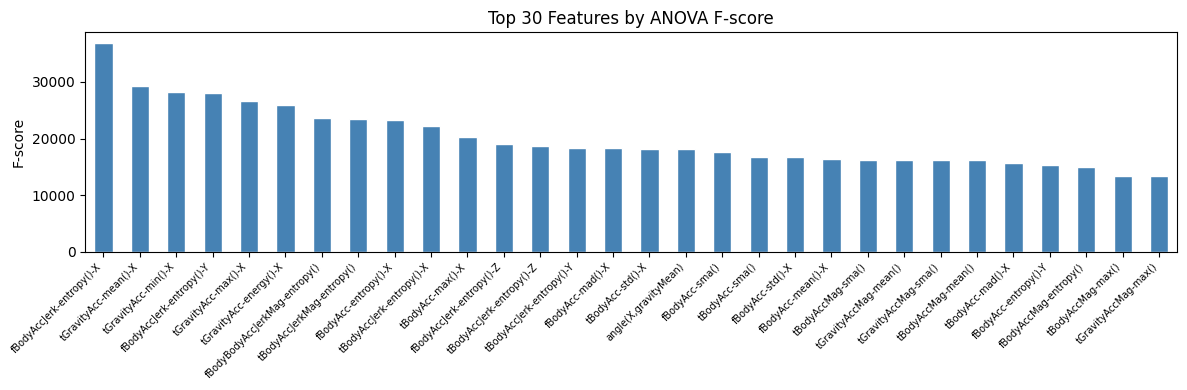

In [47]:
from sklearn.feature_selection import SelectKBest, f_classif

# Compute ANOVA F-scores for all 525 remaining features
f_selector = SelectKBest(score_func=f_classif, k='all')
f_selector.fit(X_train_clean, y_train.values.ravel())

f_scores = pd.Series(f_selector.scores_, index=kept_cols).sort_values(ascending=False)
p_values = pd.Series(f_selector.pvalues_, index=kept_cols)

print(f"Features with significant F-score (p < 0.05): {(p_values < 0.05).sum()} / {len(kept_cols)}")
print(f"\nTop 15 features by ANOVA F-score:")
print(f_scores.head(15).to_string())

plt.figure(figsize=(12, 4))
f_scores.head(30).plot(kind='bar', color='steelblue', edgecolor='white')
plt.title("Top 30 Features by ANOVA F-score")
plt.ylabel("F-score")
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.tight_layout()
plt.show()

K-sweep — accuracy vs. number of features (proxy: Logistic Regression)
------------------------------------------------------------
  k =  50  →  accuracy = 0.8975
  k = 100  →  accuracy = 0.9372
  k = 150  →  accuracy = 0.9416
  k = 200  →  accuracy = 0.9454
  k = 250  →  accuracy = 0.9511
  k = 300  →  accuracy = 0.9566
  k = 350  →  accuracy = 0.9576
  k = 400  →  accuracy = 0.9627
  k = 450  →  accuracy = 0.9603
  k = 525  →  accuracy = 0.9637

  Best k = 525  (LR accuracy = 0.9637)


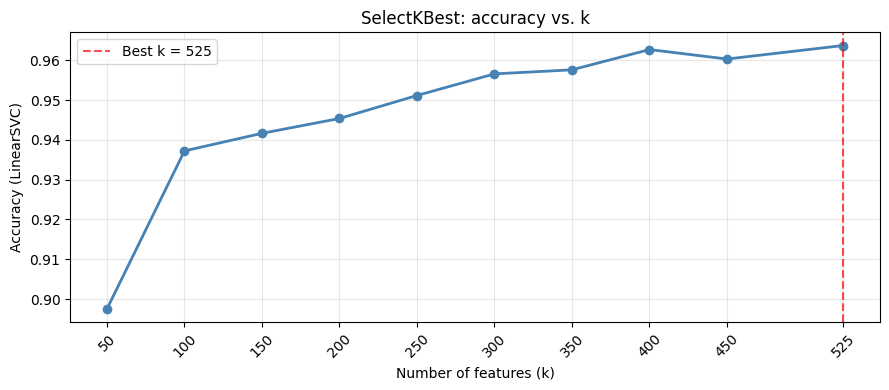

In [50]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score

# Sweep k: use LR as a fast proxy model to find the optimal number of features
k_values = [50, 100, 150, 200, 250, 300, 350, 400, 450, 525]
k_accuracies = []

print("K-sweep — accuracy vs. number of features (proxy: Logistic Regression)")
print("-" * 60)
for k in k_values:
    n = min(k, len(kept_cols))
    sel = SelectKBest(score_func=f_classif, k=n)
    sel.fit(X_train_clean, y_train.values.ravel())
    Xtr_k = sel.transform(X_train_clean)
    Xte_k = sel.transform(X_test_clean)

    lr = LinearSVC()
    lr.fit(Xtr_k, y_train.values.ravel())
    acc = accuracy_score(y_test.values.ravel(), lr.predict(Xte_k))
    k_accuracies.append(acc)
    print(f"  k = {k:3d}  →  accuracy = {acc:.4f}")

best_idx = int(np.argmax(k_accuracies))
BEST_K = k_values[best_idx]
print(f"\n  Best k = {BEST_K}  (LR accuracy = {k_accuracies[best_idx]:.4f})")

plt.figure(figsize=(9, 4))
plt.plot(k_values, k_accuracies, marker='o', linewidth=2, color='steelblue')
plt.axvline(BEST_K, color='red', linestyle='--', alpha=0.7, label=f'Best k = {BEST_K}')
plt.xlabel("Number of features (k)")
plt.ylabel("Accuracy (LinearSVC)")
plt.title("SelectKBest: accuracy vs. k")
plt.xticks(k_values, rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [51]:
# Step 1: SelectKBest with the best k found above
kb_selector = SelectKBest(score_func=f_classif, k=BEST_K)
kb_selector.fit(X_train_clean, y_train.values.ravel())
X_train_kb = kb_selector.transform(X_train_clean)
X_test_kb  = kb_selector.transform(X_test_clean)
selected_names = np.array(kept_cols)[kb_selector.get_support()]

# Step 2: Greedy correlation filter — drop feature j if it correlates > 0.95
#         with any already-kept feature i < j
corr_matrix  = np.corrcoef(X_train_kb, rowvar=False)
cols_to_drop = set()
for i in range(corr_matrix.shape[0]):
    if i in cols_to_drop:
        continue
    for j in range(i + 1, corr_matrix.shape[1]):
        if abs(corr_matrix[i, j]) > 0.95:
            cols_to_drop.add(j)

keep_mask        = np.array([i not in cols_to_drop for i in range(X_train_kb.shape[1])])
X_train_sel      = X_train_kb[:, keep_mask]
X_test_sel       = X_test_kb[:, keep_mask]
final_feat_names = selected_names[keep_mask]

print(f"Step 1 — SelectKBest (k={BEST_K})         : {X_train_kb.shape[1]:3d} features")
print(f"Step 2 — Correlation filter (|r|>0.95)    : {X_train_sel.shape[1]:3d} features")
print(f"         Removed by correlation            : {len(cols_to_drop):3d} features")
print(f"\nFinal feature matrix : {X_train_sel.shape}")

Step 1 — SelectKBest (k=525)         : 525 features
Step 2 — Correlation filter (|r|>0.95)    : 257 features
         Removed by correlation            : 268 features

Final feature matrix : (7352, 257)


## 3. Improved Models

We introduce three new model families alongside the retrained baselines:

| Model | Key idea |
|---|---|
| **Extra Trees** | Like Random Forest but splits on random thresholds — lower variance, faster training |
| **Hist Gradient Boosting** | sklearn's fast, histogram-based GBM; handles the full feature set efficiently |
| **Tuned RF / LR / SVM** | Best-performing baselines with tighter hyperparameters |

All models are trained on the final feature-selected data.

In [55]:
import models
dir(models)

['DecisionTreeClassifier',
 'ExtraTreesClassifier',
 'HistGradientBoostingClassifier',
 'KNeighborsClassifier',
 'LinearSVC',
 'LogisticRegression',
 'RandomForestClassifier',
 'SVC',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__spec__',
 'accuracy_score',
 'f1_score',
 'get_improved_models',
 'get_models',
 'precision_score',
 'recall_score',
 'time',
 'train_and_evaluate']

In [52]:
import importlib
import models as models_module

importlib.reload(models_module)
get_models = models_module.get_models
get_improved_models = models_module.get_improved_models
train_and_evaluate = models_module.train_and_evaluate

y_train_1d = y_train.values.ravel()
y_test_1d  = y_test.values.ravel()

# Baseline models retrained on the selected feature set
print("=" * 60)
print("Baseline models  (feature-selected data)")
print("=" * 60)
base_results, base_trained = train_and_evaluate(
    get_models(), X_train_sel, y_train_1d, X_test_sel, y_test_1d
)
improved_models = get_improved_models()
# Improved models on the selected feature set
print("\n" + "=" * 60)
print("Improved models  (feature-selected data)")
print("=" * 60)

impr_results, impr_trained = train_and_evaluate(
    improved_models, X_train_sel, y_train_1d, X_test_sel, y_test_1d
)

Baseline models  (feature-selected data)
Training Decision Tree...
Trained Decision Tree in 2.25 seconds.
Training Random Forest...
Trained Random Forest in 1.14 seconds.
Training Logistic Regression...
Trained Logistic Regression in 2.82 seconds.
Training Linear SVC...
Trained Linear SVC in 0.84 seconds.
Training RBF SVM...
Trained RBF SVM in 0.52 seconds.
Training K-Nearest Neighbor...
Trained K-Nearest Neighbor in 0.01 seconds.

Improved models  (feature-selected data)
Training Extra Trees...
Trained Extra Trees in 0.79 seconds.
Training Hist Gradient Boosting...
Trained Hist Gradient Boosting in 11.14 seconds.
Training Tuned Random Forest...
Trained Tuned Random Forest in 5.31 seconds.
Training Tuned Logistic Regression...
Trained Tuned Logistic Regression in 43.15 seconds.
Training Tuned RBF SVM...
Trained Tuned RBF SVM in 0.37 seconds.
Training XGBoost...
Trained XGBoost in 12.35 seconds.


Final model comparison (feature-selected data):
                    Model  Precision  Recall  F1-Score  Accuracy  Training Time
      Logistic Regression       0.95    0.95      0.95      0.95           2.82
               Linear SVC       0.95    0.95      0.95      0.95           0.84
              Extra Trees       0.95    0.95      0.95      0.95           0.79
Tuned Logistic Regression       0.95    0.95      0.95      0.95          43.15
            Random Forest       0.94    0.94      0.94      0.94           1.14
                  RBF SVM       0.94    0.94      0.94      0.94           0.52
   Hist Gradient Boosting       0.94    0.94      0.94      0.94          11.14
      Tuned Random Forest       0.94    0.94      0.94      0.94           5.31
            Tuned RBF SVM       0.94    0.94      0.94      0.94           0.37
                  XGBoost       0.94    0.94      0.94      0.94          12.35
            Decision Tree       0.84    0.84      0.84      0.84        

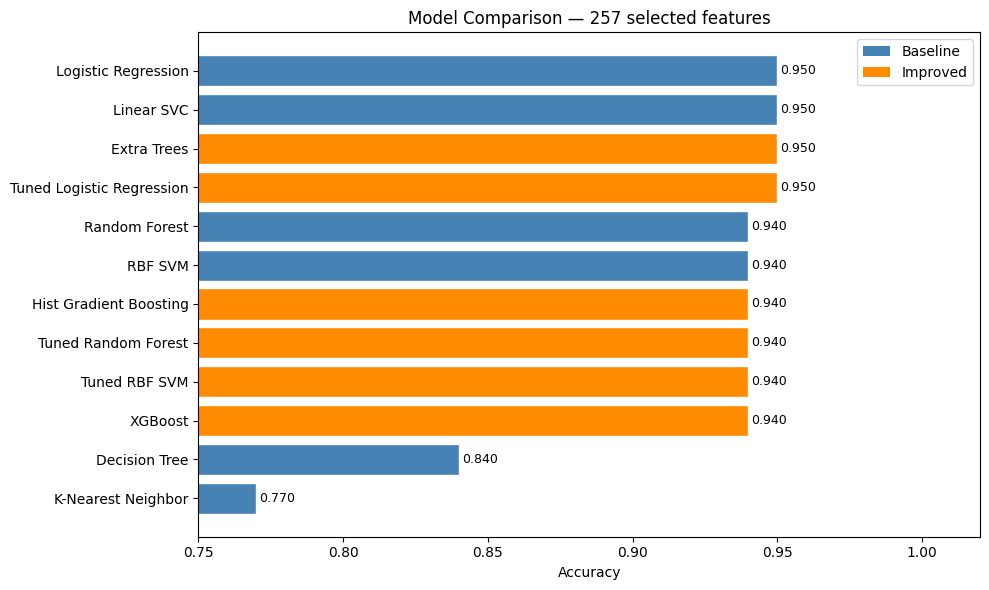

In [54]:
improved_names = set(get_improved_models().keys())
all_results = base_results + impr_results
comparison_df = (
    pd.DataFrame(all_results)
      .sort_values("Accuracy", ascending=False)
      .reset_index(drop=True)
)
comparison_df['Type'] = comparison_df['Model'].apply(
    lambda m: 'Improved' if m in improved_names else 'Baseline'
)

print("Final model comparison (feature-selected data):")
print(comparison_df.drop(columns='Type').to_string(index=False))

# Horizontal bar chart
fig, ax = plt.subplots(figsize=(10, 6))
palette = {'Baseline': 'steelblue', 'Improved': 'darkorange'}
colors   = [palette[t] for t in comparison_df['Type']]
bars     = ax.barh(comparison_df['Model'], comparison_df['Accuracy'], color=colors, edgecolor='white')

for bar, val in zip(bars, comparison_df['Accuracy']):
    ax.text(val + 0.001, bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}", va='center', fontsize=9)

ax.set_xlabel("Accuracy")
ax.set_title(f"Model Comparison — {X_train_sel.shape[1]} selected features")
ax.set_xlim(0.75, 1.02)
ax.invert_yaxis()

from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor='steelblue', label='Baseline'),
                   Patch(facecolor='darkorange', label='Improved')])
plt.tight_layout()
plt.show()

In [57]:
comparison_df.to_csv("result_after_feature_selection.csv", index=False)